In [1]:
import os
import time
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
import jax
import jax.numpy as jnp
import optax
from jax.scipy.spatial.transform import Rotation
from orbax.checkpoint import PyTreeCheckpointer
from flax.training.train_state import TrainState
from matplotlib import pyplot as plt

from lotf import LOTF_PATH
from lotf.envs import HoveringStateEnv, rollout
from lotf.envs.wrappers import MinMaxObservationWrapper
from lotf.modules import (
    MLP,
    LatentConditionedResidualDynamics,
    RecurrentTrajectoryEncoder,
)
from lotf.objects import Quadrotor

%matplotlib inline

# Joint Training of the Trajectory Encoder and Residual Dynamics

## 1. Seed

In [2]:
seed = 0
key = jax.random.key(seed)

## 2. Define Simulation Dynamics Config

In [3]:
# simulation dynamics config
sim_dyn_config = {
    "use_high_fidelity": True,           # stand-in for the disturbed/real system
    "use_forward_residual": False,       # whether to use residual dynamics in forward simulation
}

# No residual parameters are read when use_forward_residual=False. Passing an
# empty pytree avoids restoring the legacy CUDA-sharded dummy checkpoint.
dummy_residual_params = {}

## 3. Create Quadrotor Object and Data-Collection Environment

In [4]:
# simulation parameters
sim_dt = 0.02
max_sim_time = 5.0

# quadrotor object
quad_obj = Quadrotor.from_name("example_quad", sim_dyn_config)

eval_env = HoveringStateEnv(
    max_steps_in_episode=int(max_sim_time / sim_dt),
    dt=sim_dt,
    delay=0.04,
    quad_obj=quad_obj,
    margin=0.5,
    hover_target=[1.5, 0.0, 1.5],
    apply_hidden_acceleration=True,  # equation (2): v_dot += w
)
eval_env = MinMaxObservationWrapper(eval_env)

# get dims
action_dim = eval_env.action_space.shape[0]
obs_dim = eval_env.observation_space.shape[0]

print("====== eval_env info ======")
print(f"action_dim: {action_dim}")
print(f"obs_dim: {obs_dim}")

====== eval_env info ======
action_dim: 4
obs_dim: 27


## 4. Load the Trained Policy

In [5]:
policy_name = "state_hovering_params"

# create policy network
base_policy_net = MLP(
    [obs_dim, 512, 512, action_dim],
    action_bias=eval_env.hovering_action,
)

path = LOTF_PATH + "/../checkpoints/policy/" + policy_name
ckptr = PyTreeCheckpointer()
base_policy_params = ckptr.restore(path)
# define policy function
def policy_trained(obs, key):
    return base_policy_net.apply(base_policy_params, obs)

/home/dimitria/venvs/diff-sim-env/lib/python3.12/site-packages/orbax/checkpoint/type_handlers.py:1330: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


## 5. Collect Rollouts with Fixed Wind Acceleration

In [6]:
# HoveringStateEnv samples one row from wind_z_table.csv at reset. We retain
# the sampled wind acceleration for the whole rollout but ignore the paired
# CSV latent completely: the encoder must infer its own condition online.
num_rollouts = 256
key, key_rollouts = jax.random.split(key)
rollout_keys = jax.random.split(key_rollouts, num_rollouts)
parallel_rollout = jax.vmap(rollout, in_axes=(None, 0, None, None))
trajectories = parallel_rollout(
    eval_env, rollout_keys, policy_trained, dummy_residual_params
)

env_states = trajectories.state
quad_states = env_states.quadrotor_state

# Convert rotation matrices to the paper's state convention: (p, q, v).
def state_vectors(position, rotation_matrix, velocity):
    quaternion_xyzw = Rotation.from_matrix(rotation_matrix).as_quat()
    quaternion_wxyz = jnp.concatenate(
        [quaternion_xyzw[..., 3:], quaternion_xyzw[..., :3]], axis=-1
    )
    return jnp.concatenate([position, quaternion_wxyz, velocity], axis=-1)

states = state_vectors(
    quad_states.p[:, :-1], quad_states.R[:, :-1], quad_states.v[:, :-1]
)
# The action chosen from s_t is stored at the end of the successor state's
# action buffer, hence the 1: alignment below.
actions = env_states.last_actions[:, 1:, -1, :]
hidden_acceleration = env_states.hidden_acceleration[:, :-1, :]
state_actions = jnp.concatenate([states, actions], axis=-1)

# rollout(..., real_step=False) does not auto-reset. Keep the terminal
# transition itself, but discard any subsequent out-of-episode transitions.
done = jnp.logical_or(
    trajectories.terminated[:, 1:], trajectories.truncated[:, 1:]
)
valid_transition = (jnp.cumsum(done, axis=1) - done) == 0

assert states.shape[-1] == 10
assert actions.shape[-1] == 4
assert state_actions.shape[-1] == 14
assert jnp.all(hidden_acceleration == hidden_acceleration[:, :1, :])

_, rollouts_per_condition = jnp.unique(
    hidden_acceleration[:, 0, :], axis=0, return_counts=True
)
print(f"Collected {valid_transition.sum():,} valid transitions")
print(f"Conditions represented: {rollouts_per_condition.shape[0]}/17")
print(f"Rollouts per represented condition: {rollouts_per_condition}")

Collected 64,000 valid transitions
Conditions represented: 17/17
Rollouts per represented condition: [15 18 15 14 15 14  9 16 10 18 11 17 14 21 20  8 21]


## 6. Build Rolling Contexts and Residual Targets

In [ ]:
# The paper defines H_{t-C:t} from the C state-action pairs immediately before
# transition t. A new rolling context therefore produces a new z_t at every
# timestep. One z_t is shared over several following transitions so it must
# represent their common dynamics instead of memorizing a single residual.
context_length = 20
dynamics_horizon = 10
train_fraction = 0.9

num_transitions_per_rollout = state_actions.shape[1]
num_contexts_per_rollout = (
    num_transitions_per_rollout - context_length - dynamics_horizon + 1
)
assert num_contexts_per_rollout > 0

# Split whole rollouts before normalization or windowing. Overlapping windows
# from a rollout can therefore never appear in both training and validation.
key, key_split = jax.random.split(key)
rollout_permutation = jax.random.permutation(key_split, num_rollouts)
num_train_rollouts = int(train_fraction * num_rollouts)
train_rollout_indices = rollout_permutation[:num_train_rollouts]
train_rollout_mask = jnp.zeros(num_rollouts, dtype=bool)
train_rollout_mask = train_rollout_mask.at[train_rollout_indices].set(True)

normalization_mask = train_rollout_mask[:, None] & valid_transition
input_mean = state_actions[normalization_mask].mean(axis=0)
input_std = jnp.maximum(
    state_actions[normalization_mask].std(axis=0), 1e-6
)
normalized_state_actions = (state_actions - input_mean) / input_std

context_transition_indices = (
    jnp.arange(num_contexts_per_rollout)[:, None]
    + jnp.arange(context_length)[None, :]
)
target_transition_indices = (
    jnp.arange(num_contexts_per_rollout)[:, None]
    + context_length
    + jnp.arange(dynamics_horizon)[None, :]
)

rolling_contexts = normalized_state_actions[:, context_transition_indices]
rolling_dynamics_inputs = normalized_state_actions[:, target_transition_indices]
rolling_actions = actions[:, target_transition_indices]
context_valid = valid_transition[:, context_transition_indices].all(axis=-1)
targets_valid = valid_transition[:, target_transition_indices].all(axis=-1)
valid_context = context_valid & targets_valid

contexts = rolling_contexts[valid_context]
dynamics_inputs = rolling_dynamics_inputs[valid_context]
dynamics_actions = rolling_actions[valid_context]
context_rollout_grid = jnp.broadcast_to(
    jnp.arange(num_rollouts)[:, None], valid_context.shape
)
context_time_grid = jnp.broadcast_to(
    (jnp.arange(num_contexts_per_rollout) + context_length)[None, :],
    valid_context.shape,
)
context_rollout_ids = context_rollout_grid[valid_context]
context_times = context_time_grid[valid_context]

# Evaluate the nominal rigid-body prior on every target transition. Its delay
# remains identical to the data-collection environment.
prior_dyn_config = {
    "use_high_fidelity": False,
    "use_forward_residual": False,
}
prior_env = HoveringStateEnv(
    max_steps_in_episode=int(max_sim_time / sim_dt),
    dt=sim_dt,
    delay=0.04,
    quad_obj=Quadrotor.from_name("example_quad", prior_dyn_config),
    apply_hidden_acceleration=False,
    margin=0.5,
    hover_target=[1.5, 0.0, 1.5],
)

batched_transition_states = jax.tree.map(
    lambda leaf: leaf[:, target_transition_indices][valid_context], env_states
)
batched_observed_next_states = jax.tree.map(
    lambda leaf: leaf[:, target_transition_indices + 1][valid_context],
    quad_states,
)
transition_states = jax.tree.map(
    lambda leaf: leaf.reshape((-1,) + leaf.shape[2:]),
    batched_transition_states,
)
observed_next_quad_states = jax.tree.map(
    lambda leaf: leaf.reshape((-1,) + leaf.shape[2:]),
    batched_observed_next_states,
)
prior_actions = dynamics_actions.reshape(-1, action_dim)
key, key_prior = jax.random.split(key)
prior_keys = jax.random.split(key_prior, prior_actions.shape[0])

@jax.jit
def evaluate_prior(prior_states, prior_actions, prior_keys):
    def prior_step(state, action, step_key):
        transition = prior_env._step(state, action, {}, step_key)
        return transition.state.quadrotor_state

    return jax.vmap(prior_step)(prior_states, prior_actions, prior_keys)

prior_next_quad_states = evaluate_prior(
    transition_states, prior_actions, prior_keys
)

def state_difference(observed, nominal):
    # Hovering predicts translational residuals only. Orientation is advanced
    # entirely by the analytical body-rate dynamics in the physics prior.
    return jnp.concatenate(
        [observed.p - nominal.p, observed.v - nominal.v], axis=-1
    )

flat_residual_targets = state_difference(
    observed_next_quad_states, prior_next_quad_states
)
residual_targets = flat_residual_targets.reshape(
    contexts.shape[0], dynamics_horizon, -1
)
assert residual_targets.shape[-1] == 6

training_context_mask = train_rollout_mask[context_rollout_ids]
train_contexts = contexts[training_context_mask]
train_dynamics_inputs = dynamics_inputs[training_context_mask]
train_targets = residual_targets[training_context_mask]
validation_contexts = contexts[~training_context_mask]
validation_dynamics_inputs = dynamics_inputs[~training_context_mask]
validation_targets = residual_targets[~training_context_mask]
validation_rollout_ids = context_rollout_ids[~training_context_mask]
validation_context_times = context_times[~training_context_mask]
print(f"Training rollouts:   {num_train_rollouts}")
print(f"Validation rollouts: {num_rollouts - num_train_rollouts}")
print(f"Training contexts:   {train_contexts.shape[0]:,}")
print(f"Validation contexts: {validation_contexts.shape[0]:,}")
print(f"Context shape:       {train_contexts.shape[1:]}")
print(f"Targets per latent:  {dynamics_horizon}")


Training rollouts:   230
Validation rollouts: 26
Training contexts:   50,830
Validation contexts: 5,746
Context shape:       (20, 14)
Targets per latent:  10


## 7. Create the Encoder, Decoder, and FiLM Residual Dynamics

In [58]:
state_action_dim = state_actions.shape[-1]
latent_dim = 12

trajectory_encoder = RecurrentTrajectoryEncoder(
    state_action_dim=state_action_dim,
    context_length=context_length,
    latent_dim=latent_dim,
    projection_dim=128,
    hidden_dim=128,
)
residual_model = LatentConditionedResidualDynamics(
    state_action_dim=state_action_dim,
    latent_dim=latent_dim,
    hidden_dim=256,
    num_blocks=2,
    predict_orientation=False,
)
# G_eta is auxiliary: it reconstructs the complete normalized context from z.
context_decoder = MLP(
    [latent_dim, 256, 256, context_length * state_action_dim],
    nonlinearity=jax.nn.gelu,
)

key, key_encoder, key_residual, key_decoder = jax.random.split(key, 4)
joint_params = {
    "encoder": trajectory_encoder.initialize(key_encoder),
    "residual": residual_model.initialize(key_residual),
    "decoder": context_decoder.initialize(key_decoder),
}

def joint_forward(params, contexts, normalized_dynamics_inputs):
    latents = trajectory_encoder.apply(params["encoder"], contexts)
    expanded_latents = jnp.broadcast_to(
        latents[..., None, :],
        normalized_dynamics_inputs.shape[:-1] + (latent_dim,),
    )
    predicted_residuals = residual_model.apply(
        params["residual"], normalized_dynamics_inputs, expanded_latents
    )
    reconstructed_contexts = context_decoder.apply(
        params["decoder"], latents
    ).reshape(contexts.shape)
    return latents, predicted_residuals, reconstructed_contexts

joint_train_state = TrainState.create(
    apply_fn=joint_forward,
    params=joint_params,
    tx=optax.adam(learning_rate=3e-4),
)

dummy_latent, dummy_residuals, dummy_reconstruction = joint_forward(
    joint_train_state.params, train_contexts[0], train_dynamics_inputs[0]
)
assert dummy_latent.shape == (latent_dim,)
assert dummy_residuals.shape == (dynamics_horizon, 6)
assert dummy_reconstruction.shape == (context_length, state_action_dim)
print(f"Encoder output:        {dummy_latent.shape}")
print(f"Residual-head output: {dummy_residuals.shape}")
print(f"Decoder output:        {dummy_reconstruction.shape}")


Encoder output:        (12,)
Residual-head output: (20, 6)
Decoder output:        (20, 14)


## 8. Jointly Minimize $L_{dyn} + \lambda_{rec} L_{rec}$

In [ ]:
# lambda_rec is exposed explicitly because the paper does not prescribe one
# universal task-independent value. L_rec acts on normalized context channels.
lambda_rec = 1e-4
huber_delta = 1.0
batch_size = min(512, train_contexts.shape[0])
num_training_steps = 5000
print_every = 100  # Set to 1 to print every optimizer update.

def joint_loss(params, contexts, dynamics_inputs, targets):
    _, predictions, reconstructions = joint_forward(
        params, contexts, dynamics_inputs
    )
    dynamics_loss = optax.huber_loss(
        predictions, targets, delta=huber_delta
    ).mean()
    reconstruction_loss = jnp.square(
        reconstructions - contexts
    ).mean()
    total_loss = dynamics_loss + lambda_rec * reconstruction_loss
    return total_loss, (dynamics_loss, reconstruction_loss)

@jax.jit
def train_joint_model(train_state, rng_key):
    def training_step(carry, step):
        state, step_key = carry
        step_key, sample_key = jax.random.split(step_key)
        batch_indices = jax.random.randint(
            sample_key, (batch_size,), 0, train_contexts.shape[0]
        )

        (loss, (dyn_loss, rec_loss)), gradients = jax.value_and_grad(
            joint_loss, has_aux=True
        )(
            state.params,
            train_contexts[batch_indices],
            train_dynamics_inputs[batch_indices],
            train_targets[batch_indices],
        )
        state = state.apply_gradients(grads=gradients)

        def print_current_losses(_):
            jax.debug.print("L_dyn: {}", dyn_loss, ordered=True)
            jax.debug.print("L_rec: {}", rec_loss, ordered=True)
            jax.debug.print(
                "weighted L_rec: {}",
                lambda_rec * rec_loss,
                ordered=True,
            )
            return jnp.int32(0)

        should_print = (step % print_every == 0) | (
            step == num_training_steps - 1
        )
        jax.lax.cond(
            should_print,
            print_current_losses,
            lambda _: jnp.int32(0),
            operand=None,
        )
        loss_components = jnp.stack([loss, dyn_loss, rec_loss])
        return (state, step_key), loss_components

    (train_state, _), losses = jax.lax.scan(
        training_step,
        (train_state, rng_key),
        jnp.arange(num_training_steps),
    )
    return train_state, losses

initial_total, (initial_dyn, initial_rec) = joint_loss(
    joint_train_state.params,
    train_contexts[:batch_size],
    train_dynamics_inputs[:batch_size],
    train_targets[:batch_size],
)
key, key_train = jax.random.split(key)
compiled_train_joint_model = train_joint_model.lower(
    joint_train_state, key_train
).compile()
training_start_time = time.perf_counter()
joint_train_state, training_losses = compiled_train_joint_model(
    joint_train_state, key_train
)
training_losses.block_until_ready()
training_duration_seconds = time.perf_counter() - training_start_time

validation_total, (validation_dyn, validation_rec) = joint_loss(
    joint_train_state.params,
    validation_contexts,
    validation_dynamics_inputs,
    validation_targets,
)

print(f"lambda_rec:              {lambda_rec:.1e}")
print(f"Initial total loss:      {initial_total:.6e}")
print(f"Initial L_dyn:           {initial_dyn:.6e}")
print(f"Initial L_rec:           {initial_rec:.6e}")
print(f"Final minibatch total:   {training_losses[-1, 0]:.6e}")
print(f"Final minibatch L_dyn:   {training_losses[-1, 1]:.6e}")
print(f"Final minibatch L_rec:   {training_losses[-1, 2]:.6e}")
print(f"Validation total loss:   {validation_total:.6e}")
print(f"Validation L_dyn:        {validation_dyn:.6e}")
print(f"Validation L_rec:        {validation_rec:.6e}")
print(f"Training time:           {training_duration_seconds:.2f} s")


L_dyn: 4.2525840626694844e-07
L_rec: 0.0034460737369954586
weighted L_rec: 3.446073833401897e-06
L_dyn: 2.0830603375543433e-07
L_rec: 0.003445093287155032
weighted L_rec: 3.4450933981133858e-06
L_dyn: 6.218228350007848e-07
L_rec: 0.0029795393347740173
weighted L_rec: 2.9795394311804557e-06
L_dyn: 1.9935345108024194e-07
L_rec: 0.0019156988710165024
weighted L_rec: 1.9156989310431527e-06
L_dyn: 2.6918013418253395e-07
L_rec: 0.0020771031267941
weighted L_rec: 2.077103317787987e-06
L_dyn: 1.783600112048589e-07
L_rec: 0.0022001899778842926
weighted L_rec: 2.200190010626102e-06
L_dyn: 2.2592021764467063e-07
L_rec: 0.0028503721114248037
weighted L_rec: 2.850372311513638e-06
L_dyn: 2.2563119728147285e-07
L_rec: 0.001982188317924738
weighted L_rec: 1.9821884507109644e-06
L_dyn: 1.65477885616383e-07
L_rec: 0.0022112634032964706
weighted L_rec: 2.211263563367538e-06
L_dyn: 4.583405939229124e-07
L_rec: 0.0029860148206353188
weighted L_rec: 2.986015033457079e-06
L_dyn: 2.0595642524767754e-07
L_rec:

## 9. Plot the Joint Training Losses

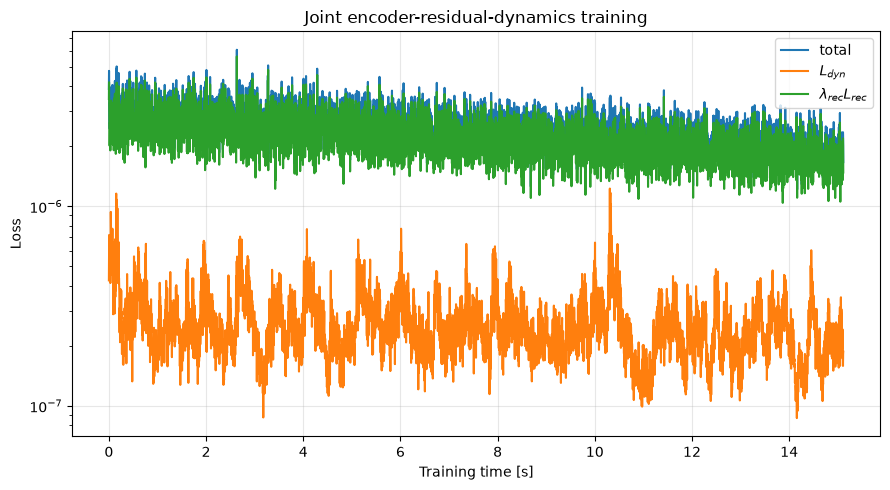

In [76]:
training_time_axis = jnp.linspace(
    0.0, training_duration_seconds, num_training_steps
)
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(training_time_axis, training_losses[:, 0], label="total")
ax.plot(training_time_axis, training_losses[:, 1], label=r"$L_{dyn}$")
ax.plot(
    training_time_axis,
    lambda_rec * training_losses[:, 2],
    label=r"$\lambda_{rec} L_{rec}$",
)
ax.set_yscale("log")
ax.set_xlabel("Training time [s]")
ax.set_ylabel("Loss")
ax.set_title("Joint encoder-residual-dynamics training")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()


## 10. Evaluate Held-Out Dynamics and Time-Varying Encoded Conditions

Held-out L_dyn:              3.033036e-07
Held-out context MSE:        5.364301e-03
Mean ||z_t - z_(t-1)||:     4.147609e-02

Per-component residual errors:
     delta_p_x: MAE=4.487404e-04, RMSE=5.578958e-04
     delta_p_y: MAE=2.336867e-04, RMSE=3.486075e-04
     delta_p_z: MAE=3.489264e-04, RMSE=4.582994e-04
     delta_v_x: MAE=6.509035e-04, RMSE=1.063229e-03
     delta_v_y: MAE=5.403045e-04, RMSE=9.468974e-04
     delta_v_z: MAE=5.838666e-04, RMSE=9.847635e-04


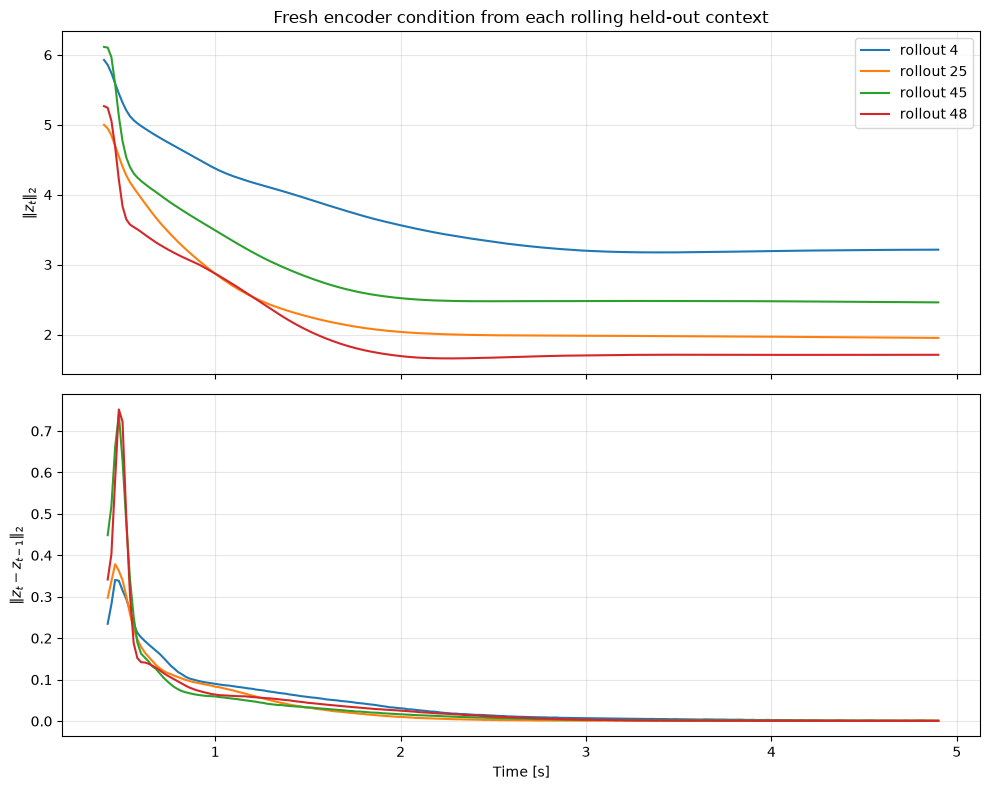

In [77]:
validation_latents, validation_predictions, _ = (
    joint_forward(
        joint_train_state.params,
        validation_contexts,
        validation_dynamics_inputs,
    )
)
validation_predictions.block_until_ready()

component_names = [
    "delta_p_x", "delta_p_y", "delta_p_z",
    "delta_v_x", "delta_v_y", "delta_v_z",
]
component_mae = jnp.abs(
    validation_predictions - validation_targets
).mean(axis=(0, 1))
component_rmse = jnp.sqrt(
    jnp.square(validation_predictions - validation_targets).mean(axis=(0, 1))
)

# Adjacent windows within one held-out rollout overlap but are encoded anew.
adjacent_same_rollout = (
    validation_rollout_ids[1:] == validation_rollout_ids[:-1]
)
latent_step_changes = jnp.linalg.norm(
    validation_latents[1:] - validation_latents[:-1], axis=-1
)[adjacent_same_rollout]

print(f"Held-out L_dyn:              {validation_dyn:.6e}")
print(f"Held-out context MSE:        {validation_rec:.6e}")
print(
    "Mean ||z_t - z_(t-1)||:     "
    f"{latent_step_changes.mean():.6e}"
)
print("\nPer-component residual errors:")
for name, mae, rmse in zip(component_names, component_mae, component_rmse):
    print(f"  {name:>12s}: MAE={mae:.6e}, RMSE={rmse:.6e}")

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
held_out_rollouts_to_plot = jnp.unique(validation_rollout_ids)[:4]
for rollout_id in held_out_rollouts_to_plot:
    rollout_mask = validation_rollout_ids == rollout_id
    rollout_time = validation_context_times[rollout_mask] * sim_dt
    rollout_latents = validation_latents[rollout_mask]
    axes[0].plot(
        rollout_time,
        jnp.linalg.norm(rollout_latents, axis=-1),
        label=f"rollout {int(rollout_id)}",
    )
    axes[1].plot(
        rollout_time[1:],
        jnp.linalg.norm(
            rollout_latents[1:] - rollout_latents[:-1], axis=-1
        ),
    )

axes[0].set_ylabel(r"$\|z_t\|_2$")
axes[0].set_title("Fresh encoder condition from each rolling held-out context")
axes[0].legend()
axes[1].set_xlabel("Time [s]")
axes[1].set_ylabel(r"$\|z_t-z_{t-1}\|_2$")
for ax in axes:
    ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


## 11. Collect Fresh Data and Evaluate One-Step Residual Predictions

Fresh one-step samples: 8,000
One-step L_dyn:        3.951859e-07

Residual error by component:
     delta_p_x: MAE=3.790315e-04, RMSE=4.983687e-04
     delta_p_y: MAE=2.420954e-04, RMSE=3.781235e-04
     delta_p_z: MAE=4.130951e-04, RMSE=5.409193e-04
     delta_v_x: MAE=7.104989e-04, RMSE=1.299656e-03
     delta_v_y: MAE=5.355644e-04, RMSE=9.616422e-04
     delta_v_z: MAE=6.202749e-04, RMSE=1.201843e-03

Physical one-step RMSE before -> after learned correction:
  position:    2.226031e-04 -> 4.774738e-04 m
  velocity:    2.227168e-02 -> 1.163083e-03 m/s


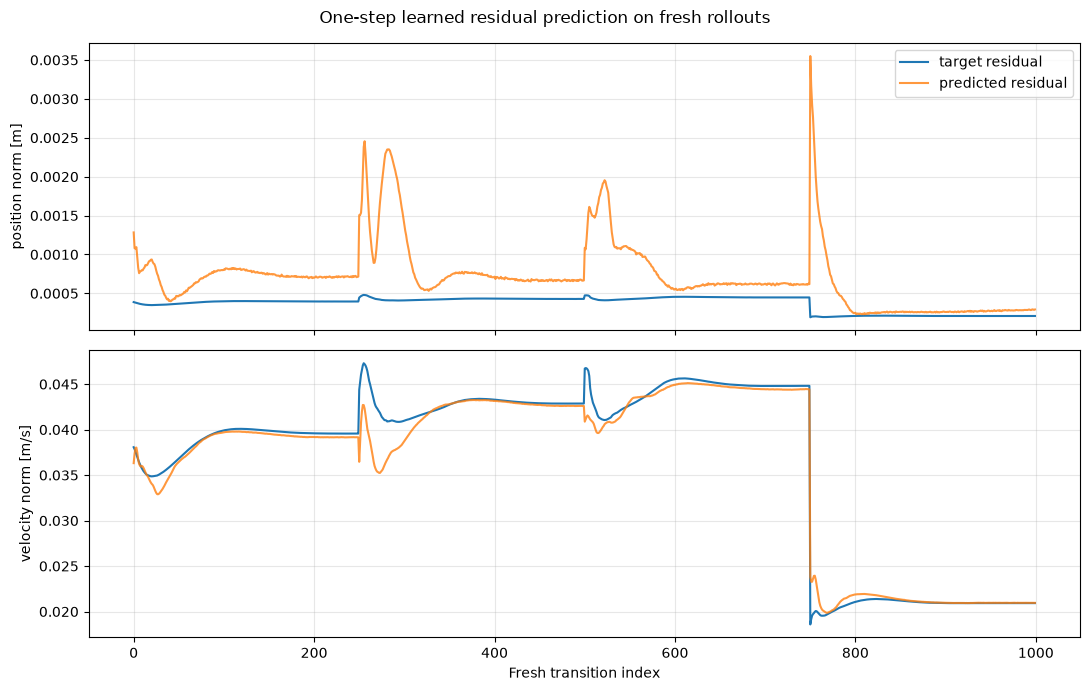

In [78]:
# This is a genuinely fresh evaluation dataset. Nothing in this cell updates
# the policy, encoder, decoder, or residual-dynamics parameters.
num_one_step_rollouts = 32
open_loop_validation_time = 5.0
one_step_num_steps = context_length + int(round(
    open_loop_validation_time / sim_dt
))
one_step_eval_env = HoveringStateEnv(
    max_steps_in_episode=one_step_num_steps,
    dt=sim_dt,
    delay=0.04,
    quad_obj=quad_obj,
    margin=0.5,
    hover_target=[1.5, 0.0, 1.5],
    apply_hidden_acceleration=True,
)
one_step_eval_env = MinMaxObservationWrapper(one_step_eval_env)
key, key_one_step_rollouts = jax.random.split(key)
one_step_rollout_keys = jax.random.split(
    key_one_step_rollouts, num_one_step_rollouts
)
one_step_trajectories = parallel_rollout(
    one_step_eval_env,
    one_step_rollout_keys,
    policy_trained,
    dummy_residual_params,
)

one_step_env_states = one_step_trajectories.state
one_step_quad_states = one_step_env_states.quadrotor_state
one_step_states = state_vectors(
    one_step_quad_states.p[:, :-1],
    one_step_quad_states.R[:, :-1],
    one_step_quad_states.v[:, :-1],
)
one_step_actions = one_step_env_states.last_actions[:, 1:, -1, :]
one_step_state_actions = jnp.concatenate(
    [one_step_states, one_step_actions], axis=-1
)
one_step_normalized_state_actions = (
    one_step_state_actions - input_mean
) / input_std

one_step_done = jnp.logical_or(
    one_step_trajectories.terminated[:, 1:],
    one_step_trajectories.truncated[:, 1:],
)
one_step_valid_transition = (
    jnp.cumsum(one_step_done, axis=1) - one_step_done
) == 0
num_one_step_contexts = (
    one_step_state_actions.shape[1] - context_length
)
one_step_context_indices = (
    jnp.arange(num_one_step_contexts)[:, None]
    + jnp.arange(context_length)[None, :]
)
one_step_target_indices = (
    jnp.arange(num_one_step_contexts) + context_length
)
one_step_valid_context = (
    one_step_valid_transition[:, one_step_context_indices].all(axis=-1)
    & one_step_valid_transition[:, one_step_target_indices]
)

one_step_contexts = one_step_normalized_state_actions[
    :, one_step_context_indices
][one_step_valid_context]
one_step_inputs = one_step_normalized_state_actions[
    :, one_step_target_indices
][one_step_valid_context]
one_step_current_states = one_step_states[
    :, one_step_target_indices
][one_step_valid_context]
one_step_target_actions = one_step_actions[
    :, one_step_target_indices
][one_step_valid_context]
one_step_hidden_accelerations = one_step_env_states.hidden_acceleration[
    :, one_step_target_indices
][one_step_valid_context]
assert jnp.all(
    one_step_env_states.hidden_acceleration
    == one_step_env_states.hidden_acceleration[:, :1, :]
)

# Run the analytical prior once from each measured pre-transition state.
one_step_prior_states = jax.tree.map(
    lambda leaf: leaf[:, one_step_target_indices][one_step_valid_context],
    one_step_env_states,
)
one_step_observed_next_states = jax.tree.map(
    lambda leaf: leaf[:, one_step_target_indices + 1][one_step_valid_context],
    one_step_quad_states,
)
key, key_one_step_prior = jax.random.split(key)
one_step_prior_keys = jax.random.split(
    key_one_step_prior, one_step_inputs.shape[0]
)
one_step_prior_next_states = evaluate_prior(
    one_step_prior_states,
    one_step_target_actions,
    one_step_prior_keys,
)
one_step_targets = state_difference(
    one_step_observed_next_states, one_step_prior_next_states
)
one_step_next_states = state_vectors(
    one_step_observed_next_states.p,
    one_step_observed_next_states.R,
    one_step_observed_next_states.v,
)

# Infer z_t from the preceding measured context and predict only transition t.
one_step_latents = trajectory_encoder.apply(
    joint_train_state.params["encoder"], one_step_contexts
)
one_step_predictions = residual_model.apply(
    joint_train_state.params["residual"],
    one_step_inputs,
    one_step_latents,
)
one_step_predictions.block_until_ready()

# Keep the complete evaluation buffer available for further analysis. The
# physical wind is diagnostic metadata only; no CSV latent is included.
one_step_dataset = {
    "context": one_step_contexts,
    "state": one_step_current_states,
    "action": one_step_target_actions,
    "next_state": one_step_next_states,
    "normalized_state_action": one_step_inputs,
    "target_residual": one_step_targets,
    "predicted_residual": one_step_predictions,
    "encoded_latent": one_step_latents,
    "hidden_acceleration_diagnostic": one_step_hidden_accelerations,
}

one_step_errors = one_step_predictions - one_step_targets
one_step_mae = jnp.abs(one_step_errors).mean(axis=0)
one_step_rmse = jnp.sqrt(jnp.square(one_step_errors).mean(axis=0))
one_step_huber = optax.huber_loss(
    one_step_predictions, one_step_targets, delta=huber_delta
).mean()

# Compare the nominal and corrected one-step physical-state predictions.
corrected_positions = (
    one_step_prior_next_states.p + one_step_predictions[:, :3]
)
corrected_velocities = (
    one_step_prior_next_states.v + one_step_predictions[:, 3:6]
)
nominal_position_rmse = jnp.sqrt(jnp.mean(jnp.square(
    one_step_prior_next_states.p - one_step_observed_next_states.p
)))
corrected_position_rmse = jnp.sqrt(jnp.mean(jnp.square(
    corrected_positions - one_step_observed_next_states.p
)))
nominal_velocity_rmse = jnp.sqrt(jnp.mean(jnp.square(
    one_step_prior_next_states.v - one_step_observed_next_states.v
)))
corrected_velocity_rmse = jnp.sqrt(jnp.mean(jnp.square(
    corrected_velocities - one_step_observed_next_states.v
)))
print(f"Fresh one-step samples: {one_step_inputs.shape[0]:,}")
print(f"One-step L_dyn:        {one_step_huber:.6e}")
print("\nResidual error by component:")
for name, mae, rmse in zip(component_names, one_step_mae, one_step_rmse):
    print(f"  {name:>12s}: MAE={mae:.6e}, RMSE={rmse:.6e}")
print("\nPhysical one-step RMSE before -> after learned correction:")
print(
    f"  position:    {nominal_position_rmse:.6e} -> "
    f"{corrected_position_rmse:.6e} m"
)
print(
    f"  velocity:    {nominal_velocity_rmse:.6e} -> "
    f"{corrected_velocity_rmse:.6e} m/s"
)
num_plot_samples = min(1000, one_step_inputs.shape[0])
plot_indices = jnp.arange(num_plot_samples)
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
head_slices = [slice(0, 3), slice(3, 6)]
head_labels = ["position", "velocity"]
head_units = ["m", "m/s"]
for ax, head_slice, head_label, head_unit in zip(
    axes, head_slices, head_labels, head_units
):
    ax.plot(
        plot_indices,
        jnp.linalg.norm(
            one_step_targets[:num_plot_samples, head_slice], axis=-1
        ),
        label="target residual",
    )
    ax.plot(
        plot_indices,
        jnp.linalg.norm(
            one_step_predictions[:num_plot_samples, head_slice], axis=-1
        ),
        label="predicted residual",
        alpha=0.8,
    )
    ax.set_ylabel(f"{head_label} norm [{head_unit}]")
    ax.grid(True, alpha=0.3)
axes[0].legend()
axes[-1].set_xlabel("Fresh transition index")
fig.suptitle("One-step learned residual prediction on fresh rollouts")
fig.tight_layout()
plt.show()


## 12. Evaluate Multi-Step Open-Loop Rollout Predictions

Open-loop evaluation rollouts: 8
Open-loop horizon:             250 steps 
                                 (5.00 s)
Rollouts valid at 5.0 s:       8
Multi-step cumulative-residual RMSE over all rollouts and times:
     position: 3.478570e+07 m
     velocity: 9.197759e+07 m/s


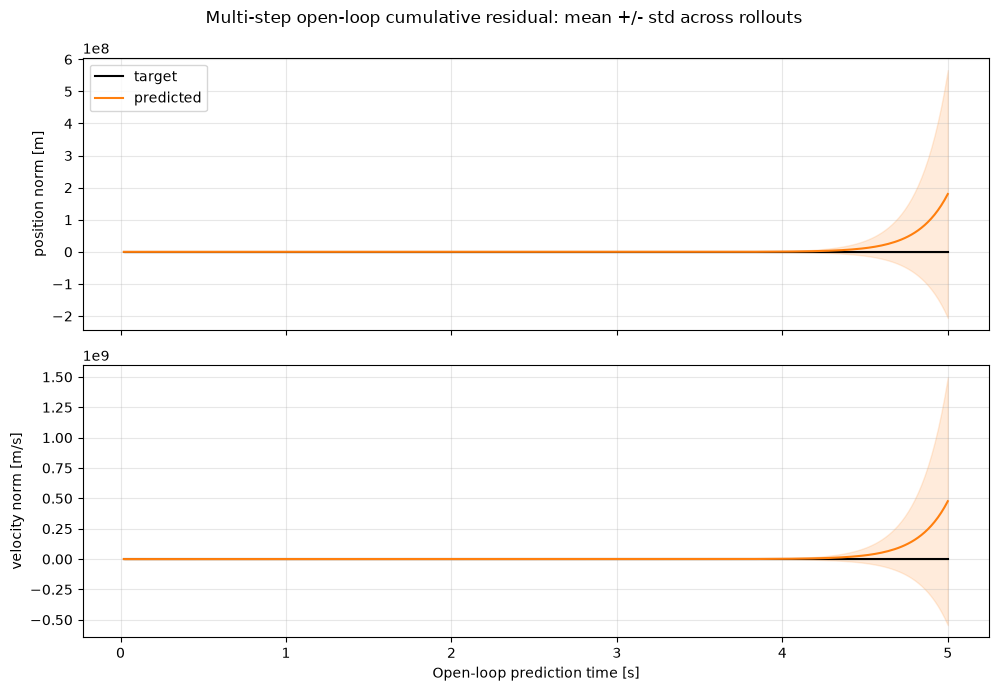

In [79]:
# Match the paper's dynamics evaluation: infer one latent from the measured
# context, then hold it fixed while recursively replaying the same recorded
# action sequence from the same measured initial state.
open_loop_horizon = int(round(open_loop_validation_time / sim_dt))
max_open_loop_rollouts = 8
assert context_length + open_loop_horizon <= one_step_state_actions.shape[1]

# Rank rollouts by their valid post-context duration. State targets after an
# actual trajectory terminates are masked rather than treated as observations.
open_loop_context_valid = one_step_valid_transition[
    :, :context_length
].all(axis=1)
open_loop_available_steps = one_step_valid_transition[
    :, context_length:context_length + open_loop_horizon
].sum(axis=1)
open_loop_scores = jnp.where(
    open_loop_context_valid, open_loop_available_steps, -1
)
open_loop_rollout_indices = jnp.argsort(open_loop_scores)[::-1][
    :min(max_open_loop_rollouts, num_one_step_rollouts)
]
assert open_loop_scores[open_loop_rollout_indices[0]] > 0, (
    "No fresh rollout is valid beyond the initial encoder context"
)
open_loop_valid_mask = one_step_valid_transition[
    open_loop_rollout_indices,
    context_length:context_length + open_loop_horizon,
]

open_loop_initial_states = jax.tree.map(
    lambda leaf: leaf[open_loop_rollout_indices, context_length],
    one_step_env_states,
)
open_loop_initial_contexts = one_step_normalized_state_actions[
    open_loop_rollout_indices, :context_length
]
open_loop_actions = one_step_actions[
    open_loop_rollout_indices,
    context_length:context_length + open_loop_horizon,
]
key, key_open_loop = jax.random.split(key)
open_loop_keys = jax.random.split(
    key_open_loop,
    open_loop_rollout_indices.shape[0] * open_loop_horizon,
).reshape(open_loop_rollout_indices.shape[0], open_loop_horizon)

def learned_open_loop(initial_state, initial_context, action_sequence, step_keys):
    fixed_latent = trajectory_encoder.apply(
        joint_train_state.params["encoder"], initial_context
    )

    def learned_step(predicted_state, step_inputs):
        action, step_key = step_inputs
        current_state = state_vectors(
            predicted_state.quadrotor_state.p,
            predicted_state.quadrotor_state.R,
            predicted_state.quadrotor_state.v,
        )
        normalized_state_action = (
            jnp.concatenate([current_state, action], axis=-1) - input_mean
        ) / input_std

        prior_transition = prior_env._step(
            predicted_state, action, {}, step_key
        )
        prior_quad_state = prior_transition.state.quadrotor_state
        predicted_residual = residual_model.apply(
            joint_train_state.params["residual"],
            normalized_state_action,
            fixed_latent,
        )
        corrected_quad_state = prior_quad_state.replace(
            p=prior_quad_state.p + predicted_residual[:3],
            v=prior_quad_state.v + predicted_residual[3:6],
        )
        corrected_state = prior_transition.state.replace(
            quadrotor_state=corrected_quad_state
        )
        outputs = (corrected_quad_state, predicted_residual)
        return corrected_state, outputs

    _, outputs = jax.lax.scan(
        learned_step,
        initial_state,
        (action_sequence, step_keys),
    )
    predicted_states, predicted_residuals = outputs
    return predicted_states, predicted_residuals, fixed_latent

def nominal_open_loop(initial_state, action_sequence, step_keys):
    def nominal_step(state, step_inputs):
        action, step_key = step_inputs
        next_state = prior_env._step(state, action, {}, step_key).state
        return next_state, next_state.quadrotor_state

    _, nominal_quad_states = jax.lax.scan(
        nominal_step, initial_state, (action_sequence, step_keys)
    )
    return nominal_quad_states

evaluate_learned_open_loop = jax.jit(jax.vmap(learned_open_loop))
evaluate_nominal_open_loop = jax.jit(jax.vmap(nominal_open_loop))
(
    open_loop_predicted_states,
    open_loop_predicted_residuals,
    open_loop_latents,
) = evaluate_learned_open_loop(
    open_loop_initial_states,
    open_loop_initial_contexts,
    open_loop_actions,
    open_loop_keys,
)
open_loop_nominal_states = evaluate_nominal_open_loop(
    open_loop_initial_states, open_loop_actions, open_loop_keys
)
open_loop_predicted_states.p.block_until_ready()

open_loop_true_states = jax.tree.map(
    lambda leaf: leaf[
        open_loop_rollout_indices,
        context_length + 1:context_length + open_loop_horizon + 1,
    ],
    one_step_quad_states,
)

# Express both true and learned trajectories as cumulative corrections to the
# same nominal open-loop rollout. These are multi-step residuals, not the
# per-transition corrections emitted internally by the residual network.
open_loop_target_cumulative_residuals = state_difference(
    open_loop_true_states, open_loop_nominal_states
)
open_loop_predicted_cumulative_residuals = state_difference(
    open_loop_predicted_states, open_loop_nominal_states
)
open_loop_cumulative_errors = (
    open_loop_predicted_cumulative_residuals
    - open_loop_target_cumulative_residuals
)
open_loop_valid_cumulative_errors = open_loop_cumulative_errors[
    open_loop_valid_mask
]

open_loop_head_slices = [slice(0, 3), slice(3, 6)]
open_loop_head_names = ["position", "velocity"]
open_loop_head_units = ["m", "m/s"]
open_loop_time = sim_dt * (jnp.arange(open_loop_horizon) + 1)

print(
    f"Open-loop evaluation rollouts: "
    f"{open_loop_rollout_indices.shape[0]}"
)
print(f"Open-loop horizon:             {open_loop_horizon} steps ")
print(f"                                 ({open_loop_time[-1]:.2f} s)")
print(
    f"Rollouts valid at {open_loop_validation_time:.1f} s:       "
    f"{open_loop_valid_mask[:, -1].sum()}"
)
print("Multi-step cumulative-residual RMSE over all rollouts and times:")
for head_name, head_slice, head_unit in zip(
    open_loop_head_names, open_loop_head_slices, open_loop_head_units
):
    head_rmse = jnp.sqrt(jnp.mean(jnp.square(
        open_loop_valid_cumulative_errors[..., head_slice]
    )))
    print(f"  {head_name:>11s}: {head_rmse:.6e} {head_unit}")

# Unlike Cell 11's flattened plot, these curves preserve rollout time. Each
# line is the mean norm across selected rollouts; shading is +/- one std.
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
for ax, head_slice, head_name, head_unit in zip(
    axes, open_loop_head_slices, open_loop_head_names, open_loop_head_units
):
    target_norm = jnp.linalg.norm(
        open_loop_target_cumulative_residuals[..., head_slice], axis=-1
    )
    prediction_norm = jnp.linalg.norm(
        open_loop_predicted_cumulative_residuals[..., head_slice], axis=-1
    )
    target_norm = jnp.where(open_loop_valid_mask, target_norm, jnp.nan)
    prediction_norm = jnp.where(
        open_loop_valid_mask, prediction_norm, jnp.nan
    )
    target_mean = jnp.nanmean(target_norm, axis=0)
    target_std = jnp.nanstd(target_norm, axis=0)
    prediction_mean = jnp.nanmean(prediction_norm, axis=0)
    prediction_std = jnp.nanstd(prediction_norm, axis=0)
    ax.plot(open_loop_time, target_mean, label="target", color="black")
    ax.fill_between(
        open_loop_time,
        target_mean - target_std,
        target_mean + target_std,
        color="black",
        alpha=0.15,
    )
    ax.plot(
        open_loop_time, prediction_mean, label="predicted", color="C1"
    )
    ax.fill_between(
        open_loop_time,
        prediction_mean - prediction_std,
        prediction_mean + prediction_std,
        color="C1",
        alpha=0.15,
    )
    ax.set_ylabel(f"{head_name} norm [{head_unit}]")
    ax.grid(True, alpha=0.3)
axes[0].legend()
axes[-1].set_xlabel("Open-loop prediction time [s]")
fig.suptitle(
    "Multi-step open-loop cumulative residual: mean +/- std across rollouts"
)
fig.tight_layout()
plt.show()


## 13. Repeat Joint Training with Normalized Residual Targets

In [103]:
# Compute target statistics from training rollouts only. Each of the six output
# coordinates is standardized independently; validation data never contributes.
# lambda_rec is exposed explicitly because the paper does not prescribe one
# universal task-independent value. L_rec acts on normalized context channels.
lambda_rec = 1e-4
huber_delta = 1.0
batch_size = min(512, train_contexts.shape[0])
num_training_steps = 5000
print_every = 100  # Set to 1 to print every optimizer update.

residual_target_mean = train_targets.mean(axis=(0, 1))
residual_target_std = jnp.maximum(
    train_targets.std(axis=(0, 1)), 1e-8
)
normalized_train_targets = (
    train_targets - residual_target_mean
) / residual_target_std
normalized_validation_targets = (
    validation_targets - residual_target_mean
) / residual_target_std

print("Training residual-target statistics:")
for name, mean, std in zip(
    component_names, residual_target_mean, residual_target_std
):
    print(f"  {name:>10s}: mean={mean:.6e}, std={std:.6e}")

# Reuse the original initialization keys for a controlled comparison. These are
# new parameter trees and do not modify the preceding raw-target experiment.
target_normalized_joint_params = {
    "encoder": trajectory_encoder.initialize(key_encoder),
    "residual": residual_model.initialize(key_residual),
    "decoder": context_decoder.initialize(key_decoder),
}
target_normalized_train_state = TrainState.create(
    apply_fn=joint_forward,
    params=target_normalized_joint_params,
    tx=optax.adam(learning_rate=3e-4),
)

def target_normalized_joint_loss(
    params, contexts, dynamics_inputs, normalized_targets
):
    _, normalized_predictions, reconstructions = joint_forward(
        params, contexts, dynamics_inputs
    )
    dynamics_loss = optax.huber_loss(
        normalized_predictions, normalized_targets, delta=huber_delta
    ).mean()
    reconstruction_loss = jnp.square(
        reconstructions - contexts
    ).mean()
    total_loss = dynamics_loss + lambda_rec * reconstruction_loss
    return total_loss, (dynamics_loss, reconstruction_loss)

@jax.jit
def train_target_normalized_model(train_state, rng_key):
    def training_step(carry, step):
        state, step_key = carry
        step_key, sample_key = jax.random.split(step_key)
        batch_indices = jax.random.randint(
            sample_key, (batch_size,), 0, train_contexts.shape[0]
        )
        (loss, (dyn_loss, rec_loss)), gradients = jax.value_and_grad(
            target_normalized_joint_loss, has_aux=True
        )(
            state.params,
            train_contexts[batch_indices],
            train_dynamics_inputs[batch_indices],
            normalized_train_targets[batch_indices],
        )
        state = state.apply_gradients(grads=gradients)

        def print_current_losses(_):
            jax.debug.print(
                "Target-normalized training step {}", step, ordered=True
            )
            jax.debug.print("L_dyn: {}", dyn_loss, ordered=True)
            jax.debug.print("L_rec: {}", rec_loss, ordered=True)
            jax.debug.print(
                "weighted L_rec: {}",
                lambda_rec * rec_loss,
                ordered=True,
            )
            return jnp.int32(0)

        should_print = (step % print_every == 0) | (
            step == num_training_steps - 1
        )
        jax.lax.cond(
            should_print,
            print_current_losses,
            lambda _: jnp.int32(0),
            operand=None,
        )
        loss_components = jnp.stack([loss, dyn_loss, rec_loss])
        return (state, step_key), loss_components

    (train_state, _), losses = jax.lax.scan(
        training_step,
        (train_state, rng_key),
        jnp.arange(num_training_steps),
    )
    return train_state, losses

target_normalized_initial_total, (
    target_normalized_initial_dyn,
    target_normalized_initial_rec,
) = target_normalized_joint_loss(
    target_normalized_train_state.params,
    train_contexts[:batch_size],
    train_dynamics_inputs[:batch_size],
    normalized_train_targets[:batch_size],
)
# Reuse the raw-target experiment's immutable PRNG key so both runs draw the
# same minibatch-index sequence.
key_target_normalized_train = key_train
compiled_train_target_normalized_model = train_target_normalized_model.lower(
    target_normalized_train_state, key_target_normalized_train
).compile()
target_normalized_training_start = time.perf_counter()
target_normalized_train_state, target_normalized_training_losses = (
    compiled_train_target_normalized_model(
        target_normalized_train_state, key_target_normalized_train
    )
)
target_normalized_training_losses.block_until_ready()
target_normalized_training_duration = (
    time.perf_counter() - target_normalized_training_start
)
target_normalized_validation_total, (
    target_normalized_validation_dyn,
    target_normalized_validation_rec,
) = target_normalized_joint_loss(
    target_normalized_train_state.params,
    validation_contexts,
    validation_dynamics_inputs,
    normalized_validation_targets,
)

print(f"Initial normalized-target total: {target_normalized_initial_total:.6e}")
print(f"Initial normalized L_dyn:        {target_normalized_initial_dyn:.6e}")
print(f"Initial L_rec:                   {target_normalized_initial_rec:.6e}")
print(
    f"Final normalized-target total:   "
    f"{target_normalized_training_losses[-1, 0]:.6e}"
)
print(
    f"Final normalized L_dyn:          "
    f"{target_normalized_training_losses[-1, 1]:.6e}"
)
print(
    f"Final L_rec:                     "
    f"{target_normalized_training_losses[-1, 2]:.6e}"
)
print(f"Validation normalized L_dyn:     {target_normalized_validation_dyn:.6e}")
print(f"Validation L_rec:                {target_normalized_validation_rec:.6e}")
print(f"Training time:                   {target_normalized_training_duration:.2f} s")


Training residual-target statistics:
   delta_p_x: mean=6.546009e-06, std=2.184525e-04
   delta_p_y: mean=2.136557e-05, std=1.995361e-04
   delta_p_z: mean=7.000857e-05, std=2.350825e-04
   delta_v_x: mean=6.542605e-04, std=2.186887e-02
   delta_v_y: mean=2.138606e-03, std=1.997687e-02
   delta_v_z: mean=7.005494e-03, std=2.350976e-02
Target-normalized training step 0
L_dyn: 0.4561621844768524
L_rec: 0.8804067969322205
weighted L_rec: 8.804068056633696e-05
Target-normalized training step 100
L_dyn: 0.006833850871771574
L_rec: 0.5893982648849487
weighted L_rec: 5.893982597626746e-05
Target-normalized training step 200
L_dyn: 0.0035375903826206923
L_rec: 0.39645615220069885
weighted L_rec: 3.964561255997978e-05
Target-normalized training step 300
L_dyn: 0.002121906029060483
L_rec: 0.29399996995925903
weighted L_rec: 2.9399996492429636e-05
Target-normalized training step 400
L_dyn: 0.0015090175438672304
L_rec: 0.24785847961902618
weighted L_rec: 2.4785847926978022e-05
Target-normalized tr

## 14. Plot Target-Normalized Training Losses

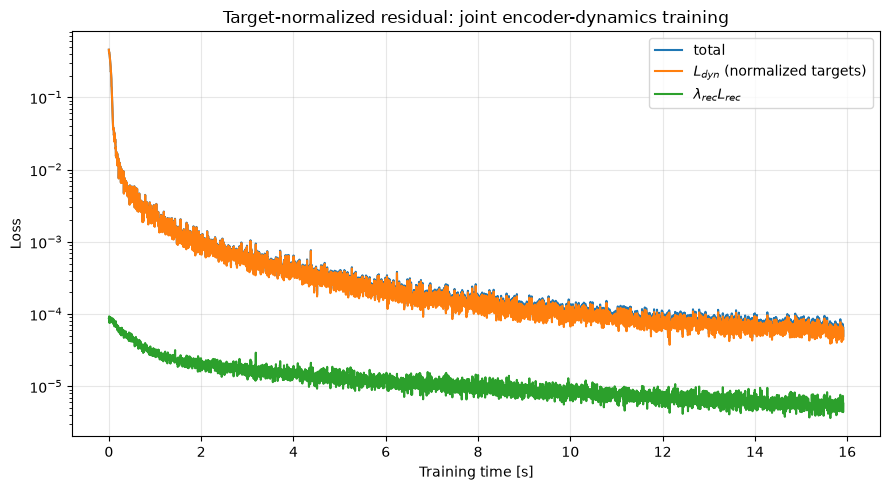

In [104]:
target_normalized_training_time_axis = jnp.linspace(
    0.0, target_normalized_training_duration, num_training_steps
)
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(
    target_normalized_training_time_axis,
    target_normalized_training_losses[:, 0],
    label="total",
)
ax.plot(
    target_normalized_training_time_axis,
    target_normalized_training_losses[:, 1],
    label=r"$L_{dyn}$ (normalized targets)",
)
ax.plot(
    target_normalized_training_time_axis,
    lambda_rec * target_normalized_training_losses[:, 2],
    label=r"$\lambda_{rec} L_{rec}$",
)
ax.set_yscale("log")
ax.set_xlabel("Training time [s]")
ax.set_ylabel("Loss")
ax.set_title("Target-normalized residual: joint encoder-dynamics training")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()


## 15. Validate the Target-Normalized Model

Held-out physical residual errors (target-normalized training):
   delta_p_x: MAE=6.071990e-06, RMSE=1.485861e-05
   delta_p_y: MAE=4.389243e-06, RMSE=9.693205e-06
   delta_p_z: MAE=6.450551e-06, RMSE=1.607014e-05
   delta_v_x: MAE=6.058367e-04, RMSE=1.481282e-03
   delta_v_y: MAE=4.386333e-04, RMSE=9.605447e-04
   delta_v_z: MAE=6.212234e-04, RMSE=1.588633e-03

Fresh one-step errors (target-normalized training):
Normalized-target L_dyn: 3.123842e-03
   delta_p_x: MAE=1.137169e-05, RMSE=1.711476e-05
   delta_p_y: MAE=1.168927e-05, RMSE=1.442120e-05
   delta_p_z: MAE=1.409523e-05, RMSE=2.064166e-05
   delta_v_x: MAE=1.138601e-03, RMSE=1.686418e-03
   delta_v_y: MAE=1.163315e-03, RMSE=1.443048e-03
   delta_v_z: MAE=1.395852e-03, RMSE=2.002147e-03
Physical one-step RMSE before -> after target-normalized correction:
  position: 2.226031e-04 -> 1.757793e-05 m
  velocity: 2.227168e-02 -> 1.725783e-03 m/s


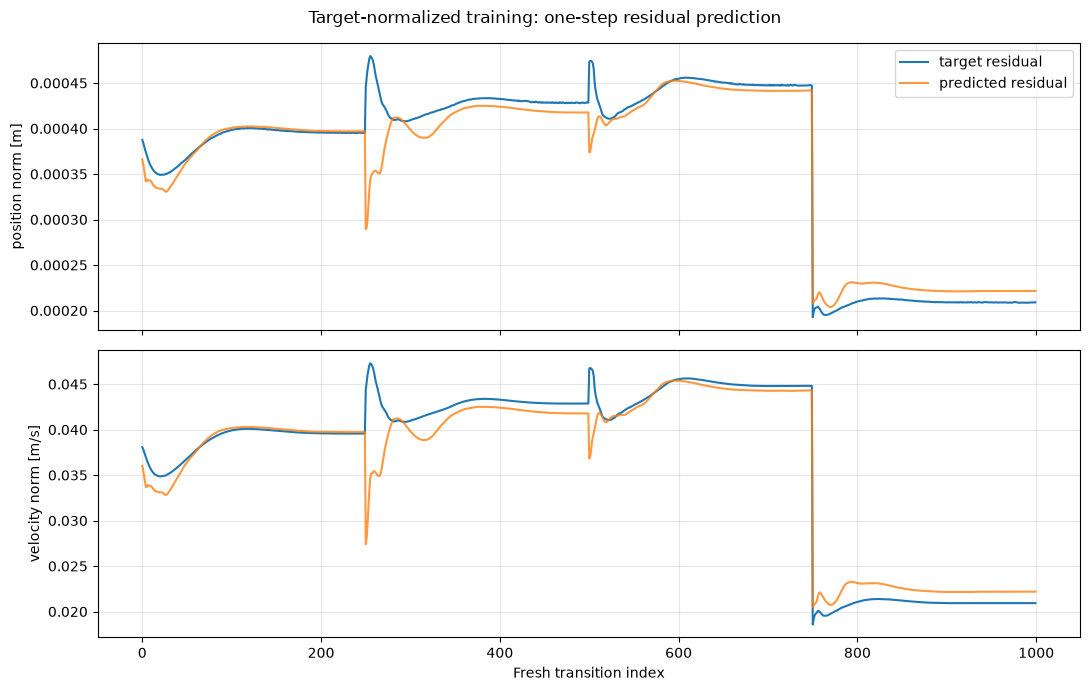

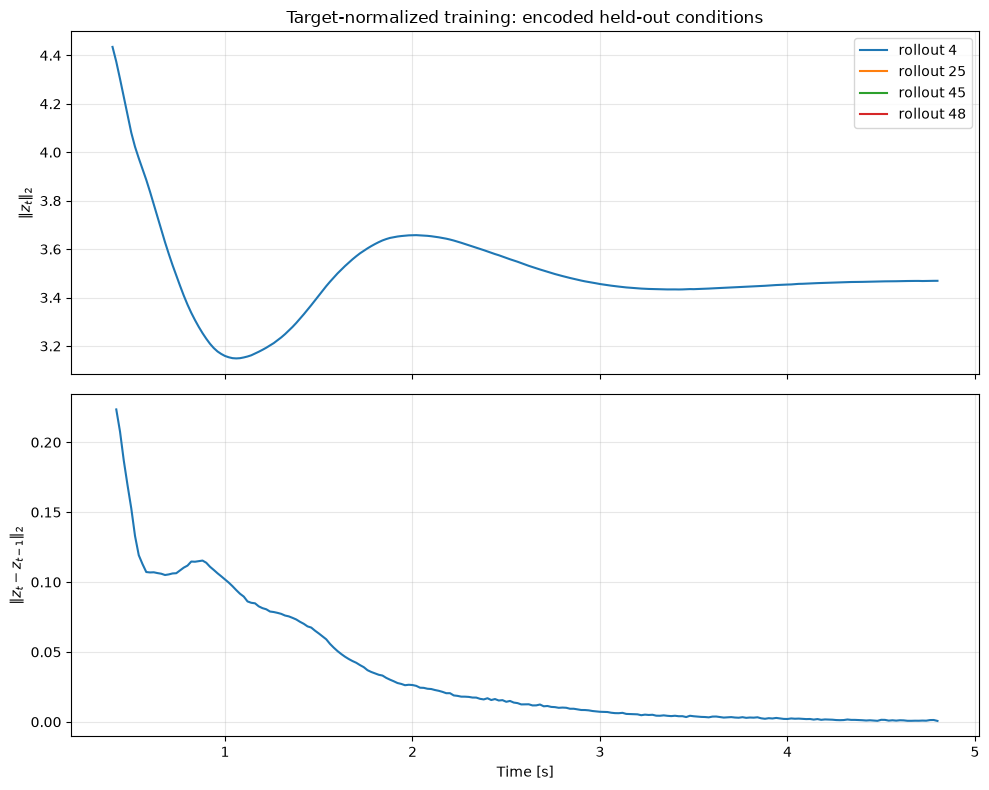

In [105]:
# Held-out contexts from the original rollout-wise split. Convert model outputs
# back to physical residual units before reporting errors.
(
    target_normalized_validation_latents,
    target_normalized_validation_predictions_norm,
    _,
) = joint_forward(
    target_normalized_train_state.params,
    validation_contexts,
    validation_dynamics_inputs,
)
target_normalized_validation_predictions = (
    target_normalized_validation_predictions_norm * residual_target_std
    + residual_target_mean
)
target_normalized_validation_predictions.block_until_ready()
target_normalized_validation_errors = (
    target_normalized_validation_predictions - validation_targets
)
target_normalized_component_mae = jnp.abs(
    target_normalized_validation_errors
).mean(axis=(0, 1))
target_normalized_component_rmse = jnp.sqrt(jnp.square(
    target_normalized_validation_errors
).mean(axis=(0, 1)))

print("Held-out physical residual errors (target-normalized training):")
for name, mae, rmse in zip(
    component_names,
    target_normalized_component_mae,
    target_normalized_component_rmse,
):
    print(f"  {name:>10s}: MAE={mae:.6e}, RMSE={rmse:.6e}")

# Re-evaluate the same fresh one-step dataset used by Cell 11.
target_normalized_one_step_latents = trajectory_encoder.apply(
    target_normalized_train_state.params["encoder"], one_step_contexts
)
target_normalized_one_step_predictions_norm = residual_model.apply(
    target_normalized_train_state.params["residual"],
    one_step_inputs,
    target_normalized_one_step_latents,
)
target_normalized_one_step_predictions = (
    target_normalized_one_step_predictions_norm * residual_target_std
    + residual_target_mean
)
target_normalized_one_step_errors = (
    target_normalized_one_step_predictions - one_step_targets
)
target_normalized_one_step_mae = jnp.abs(
    target_normalized_one_step_errors
).mean(axis=0)
target_normalized_one_step_rmse = jnp.sqrt(jnp.square(
    target_normalized_one_step_errors
).mean(axis=0))
target_normalized_one_step_huber = optax.huber_loss(
    target_normalized_one_step_predictions_norm,
    (one_step_targets - residual_target_mean) / residual_target_std,
    delta=huber_delta,
).mean()

target_normalized_corrected_positions = (
    one_step_prior_next_states.p
    + target_normalized_one_step_predictions[:, :3]
)
target_normalized_corrected_velocities = (
    one_step_prior_next_states.v
    + target_normalized_one_step_predictions[:, 3:6]
)
target_normalized_corrected_position_rmse = jnp.sqrt(jnp.mean(jnp.square(
    target_normalized_corrected_positions - one_step_observed_next_states.p
)))
target_normalized_corrected_velocity_rmse = jnp.sqrt(jnp.mean(jnp.square(
    target_normalized_corrected_velocities - one_step_observed_next_states.v
)))

print("\nFresh one-step errors (target-normalized training):")
print(f"Normalized-target L_dyn: {target_normalized_one_step_huber:.6e}")
for name, mae, rmse in zip(
    component_names,
    target_normalized_one_step_mae,
    target_normalized_one_step_rmse,
):
    print(f"  {name:>10s}: MAE={mae:.6e}, RMSE={rmse:.6e}")
print("Physical one-step RMSE before -> after target-normalized correction:")
print(
    f"  position: {nominal_position_rmse:.6e} -> "
    f"{target_normalized_corrected_position_rmse:.6e} m"
)
print(
    f"  velocity: {nominal_velocity_rmse:.6e} -> "
    f"{target_normalized_corrected_velocity_rmse:.6e} m/s"
)

num_target_normalized_plot_samples = min(
    1000, one_step_inputs.shape[0]
)
target_normalized_plot_indices = jnp.arange(
    num_target_normalized_plot_samples
)
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
for ax, head_slice, head_label, head_unit in zip(
    axes, head_slices, head_labels, head_units
):
    ax.plot(
        target_normalized_plot_indices,
        jnp.linalg.norm(
            one_step_targets[
                :num_target_normalized_plot_samples, head_slice
            ],
            axis=-1,
        ),
        label="target residual",
    )
    ax.plot(
        target_normalized_plot_indices,
        jnp.linalg.norm(
            target_normalized_one_step_predictions[
                :num_target_normalized_plot_samples, head_slice
            ],
            axis=-1,
        ),
        label="predicted residual",
        alpha=0.8,
    )
    ax.set_ylabel(f"{head_label} norm [{head_unit}]")
    ax.grid(True, alpha=0.3)
axes[0].legend()
axes[-1].set_xlabel("Fresh transition index")
fig.suptitle(
    "Target-normalized training: one-step residual prediction"
)
fig.tight_layout()
plt.show()

# Show how the newly trained encoder varies across held-out real contexts.
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
for rollout_id in held_out_rollouts_to_plot:
    rollout_mask = validation_rollout_ids == rollout_id
    rollout_time = validation_context_times[rollout_mask] * sim_dt
    rollout_latents = target_normalized_validation_latents[rollout_mask]
    axes[0].plot(
        rollout_time,
        jnp.linalg.norm(rollout_latents, axis=-1),
        label=f"rollout {int(rollout_id)}",
    )
    axes[1].plot(
        rollout_time[1:],
        jnp.linalg.norm(
            rollout_latents[1:] - rollout_latents[:-1], axis=-1
        ),
    )
axes[0].set_ylabel(r"$\|z_t\|_2$")
axes[0].set_title(
    "Target-normalized training: encoded held-out conditions"
)
axes[0].legend()
axes[1].set_xlabel("Time [s]")
axes[1].set_ylabel(r"$\|z_t-z_{t-1}\|_2$")
for ax in axes:
    ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


## 16. Five-Second Open-Loop Validation after Target-Normalized Training

Target-normalized five-second open-loop cumulative-residual RMSE:
     position: 2.204030e+01 m
     velocity: 3.586969e+01 m/s


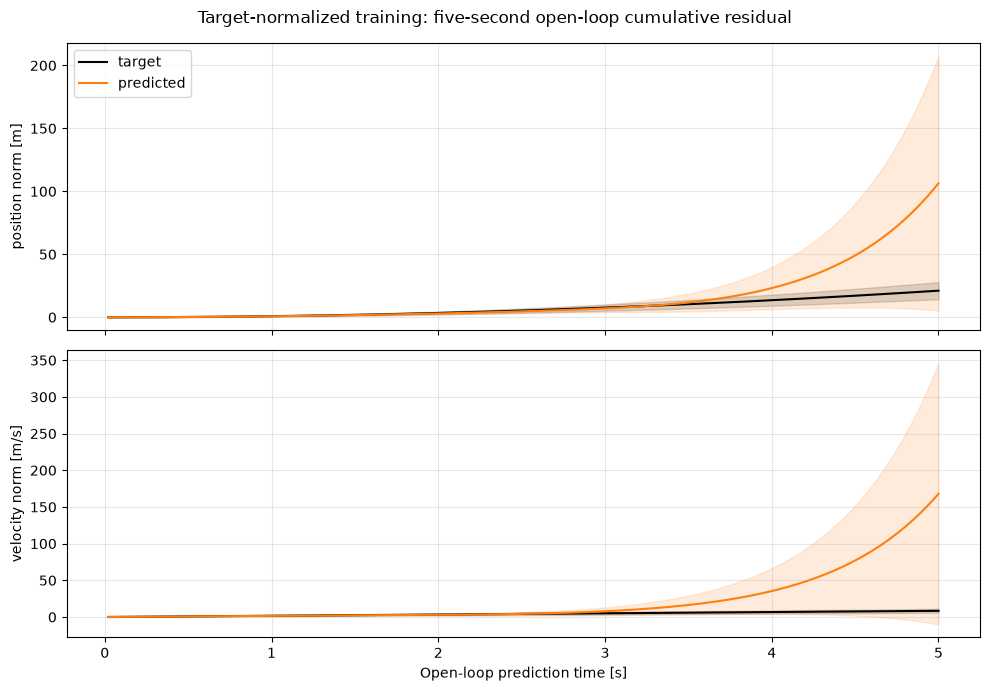

In [106]:
# The paper-style protocol is unchanged: infer one latent from the measured
# context, hold it fixed, and replay the same actions recursively for 5 s.
def target_normalized_learned_open_loop(
    initial_state, initial_context, action_sequence, step_keys
):
    fixed_latent = trajectory_encoder.apply(
        target_normalized_train_state.params["encoder"], initial_context
    )

    def learned_step(predicted_state, step_inputs):
        action, step_key = step_inputs
        current_state = state_vectors(
            predicted_state.quadrotor_state.p,
            predicted_state.quadrotor_state.R,
            predicted_state.quadrotor_state.v,
        )
        normalized_state_action = (
            jnp.concatenate([current_state, action], axis=-1) - input_mean
        ) / input_std
        prior_transition = prior_env._step(
            predicted_state, action, {}, step_key
        )
        prior_quad_state = prior_transition.state.quadrotor_state
        predicted_residual_norm = residual_model.apply(
            target_normalized_train_state.params["residual"],
            normalized_state_action,
            fixed_latent,
        )
        predicted_residual = (
            predicted_residual_norm * residual_target_std
            + residual_target_mean
        )
        corrected_quad_state = prior_quad_state.replace(
            p=prior_quad_state.p + predicted_residual[:3],
            v=prior_quad_state.v + predicted_residual[3:6],
        )
        corrected_state = prior_transition.state.replace(
            quadrotor_state=corrected_quad_state
        )
        return corrected_state, (corrected_quad_state, predicted_residual)

    _, outputs = jax.lax.scan(
        learned_step,
        initial_state,
        (action_sequence, step_keys),
    )
    predicted_states, predicted_residuals = outputs
    return predicted_states, predicted_residuals, fixed_latent

evaluate_target_normalized_open_loop = jax.jit(
    jax.vmap(target_normalized_learned_open_loop)
)
(
    target_normalized_open_loop_states,
    target_normalized_open_loop_residuals,
    target_normalized_open_loop_latents,
) = evaluate_target_normalized_open_loop(
    open_loop_initial_states,
    open_loop_initial_contexts,
    open_loop_actions,
    open_loop_keys,
)
target_normalized_open_loop_states.p.block_until_ready()

target_normalized_open_loop_cumulative_residuals = state_difference(
    target_normalized_open_loop_states, open_loop_nominal_states
)
target_normalized_open_loop_errors = (
    target_normalized_open_loop_cumulative_residuals
    - open_loop_target_cumulative_residuals
)
target_normalized_valid_open_loop_errors = (
    target_normalized_open_loop_errors[open_loop_valid_mask]
)

print(
    "Target-normalized five-second open-loop cumulative-residual RMSE:"
)
for head_name, head_slice, head_unit in zip(
    open_loop_head_names, open_loop_head_slices, open_loop_head_units
):
    head_rmse = jnp.sqrt(jnp.mean(jnp.square(
        target_normalized_valid_open_loop_errors[..., head_slice]
    )))
    print(f"  {head_name:>11s}: {head_rmse:.6e} {head_unit}")

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
for ax, head_slice, head_name, head_unit in zip(
    axes, open_loop_head_slices, open_loop_head_names, open_loop_head_units
):
    target_norm = jnp.linalg.norm(
        open_loop_target_cumulative_residuals[..., head_slice], axis=-1
    )
    prediction_norm = jnp.linalg.norm(
        target_normalized_open_loop_cumulative_residuals[..., head_slice],
        axis=-1,
    )
    target_norm = jnp.where(open_loop_valid_mask, target_norm, jnp.nan)
    prediction_norm = jnp.where(
        open_loop_valid_mask, prediction_norm, jnp.nan
    )
    target_curve_mean = jnp.nanmean(target_norm, axis=0)
    target_curve_std = jnp.nanstd(target_norm, axis=0)
    prediction_curve_mean = jnp.nanmean(prediction_norm, axis=0)
    prediction_curve_std = jnp.nanstd(prediction_norm, axis=0)
    ax.plot(
        open_loop_time, target_curve_mean, label="target", color="black"
    )
    ax.fill_between(
        open_loop_time,
        target_curve_mean - target_curve_std,
        target_curve_mean + target_curve_std,
        color="black",
        alpha=0.15,
    )
    ax.plot(
        open_loop_time,
        prediction_curve_mean,
        label="predicted",
        color="C1",
    )
    ax.fill_between(
        open_loop_time,
        prediction_curve_mean - prediction_curve_std,
        prediction_curve_mean + prediction_curve_std,
        color="C1",
        alpha=0.15,
    )
    ax.set_ylabel(f"{head_name} norm [{head_unit}]")
    ax.grid(True, alpha=0.3)
axes[0].legend()
axes[-1].set_xlabel("Open-loop prediction time [s]")
fig.suptitle(
    "Target-normalized training: five-second open-loop cumulative residual"
)
fig.tight_layout()
plt.show()
